   loan_amnt  term  int_rate  annual_inc loan_status
0       5000    36      10.5       50000  Fully Paid
1      10000    36      13.2       65000     Default
2      15000    60      15.6       72000  Fully Paid
3      20000    60      18.4       40000     Default
4      12000    36       9.8       85000  Fully Paid

Average Loan Amount:
12400.0

Average Income:
62400.0


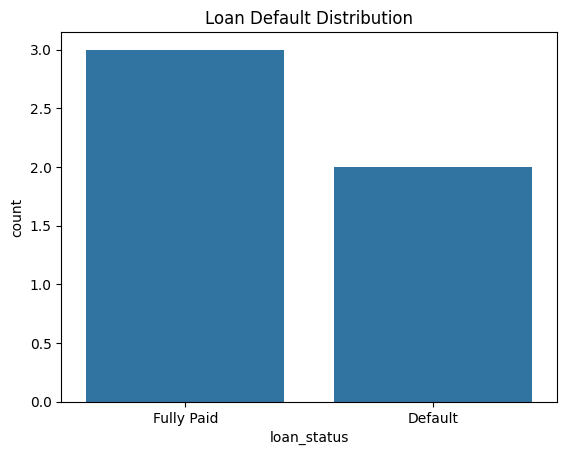

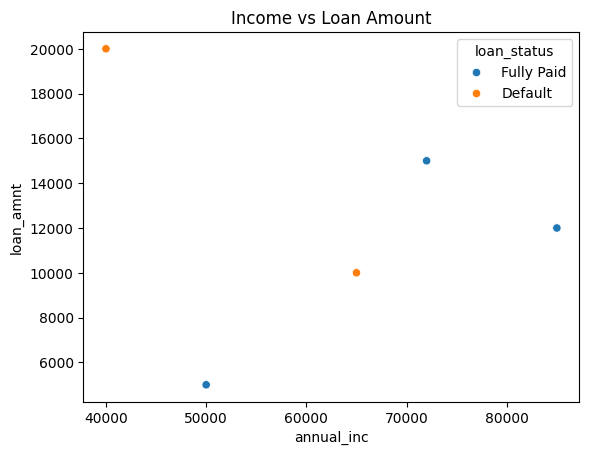


Risk Levels
   int_rate   risk_level
0      10.5  Medium Risk
1      13.2  Medium Risk
2      15.6    High Risk
3      18.4    High Risk
4       9.8     Low Risk

R2 Score:
-95.05244415044925



Project Executed Successfully


In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import plotly.express as px

data = {
    'loan_amnt': [5000, 10000, 15000, 20000, 12000],
    'term': [36, 36, 60, 60, 36],
    'int_rate': [10.5, 13.2, 15.6, 18.4, 9.8],
    'annual_inc': [50000, 65000, 72000, 40000, 85000],
    'loan_status': ['Fully Paid', 'Default', 'Fully Paid', 'Default', 'Fully Paid']
}

df = pd.DataFrame(data)

print(df)

print("\nAverage Loan Amount:")
print(df['loan_amnt'].mean())

print("\nAverage Income:")
print(df['annual_inc'].mean())

sns.countplot(x='loan_status', data=df)

plt.title("Loan Default Distribution")

plt.show()

sns.scatterplot(
    x='annual_inc',
    y='loan_amnt',
    hue='loan_status',
    data=df
)

plt.title("Income vs Loan Amount")

plt.show()

def risk(rate):

    if rate > 15:
        return "High Risk"

    elif rate > 10:
        return "Medium Risk"

    else:
        return "Low Risk"

df['risk_level'] = df['int_rate'].apply(risk)

print("\nRisk Levels")
print(df[['int_rate', 'risk_level']])

X = df[['annual_inc', 'int_rate', 'term']]

y = df['loan_amnt']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4, # Changed from 0.2 to 0.4 to ensure at least two samples in the test set
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

score = r2_score(y_test, y_pred)

print("\nR2 Score:")
print(score)

fig = px.scatter(
    df,
    x='annual_inc',
    y='loan_amnt',
    color='loan_status',
    title='Income vs Loan Amount'
)

fig.show()

print("\nProject Executed Successfully")